In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [4]:
data = fetch_openml(
    name="diabetes",
    version=1,
    as_frame=True
)

df = data.frame

print(df.head())
print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns)

/home/projectlab/.local/lib/python3.8/site-packages/sklearn/datasets/_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


   preg   plas  pres  skin   insu  mass   pedi   age            class
0   6.0  148.0  72.0  35.0    0.0  33.6  0.627  50.0  tested_positive
1   1.0   85.0  66.0  29.0    0.0  26.6  0.351  31.0  tested_negative
2   8.0  183.0  64.0   0.0    0.0  23.3  0.672  32.0  tested_positive
3   1.0   89.0  66.0  23.0   94.0  28.1  0.167  21.0  tested_negative
4   0.0  137.0  40.0  35.0  168.0  43.1  2.288  33.0  tested_positive

Shape: (768, 9)

Columns:
Index(['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age', 'class'], dtype='object')


In [5]:

X = df.drop(columns=["class"])
y = df["class"]

y = y.map({"tested_positive": 1, "tested_negative": 0})

X = X.apply(pd.to_numeric, errors="coerce")

X = X.fillna(X.median())

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   preg   plas  pres  skin   insu  mass   pedi   age
0   6.0  148.0  72.0  35.0    0.0  33.6  0.627  50.0
1   1.0   85.0  66.0  29.0    0.0  26.6  0.351  31.0
2   8.0  183.0  64.0   0.0    0.0  23.3  0.672  32.0
3   1.0   89.0  66.0  23.0   94.0  28.1  0.167  21.0
4   0.0  137.0  40.0  35.0  168.0  43.1  2.288  33.0

Target:
0    1
1    0
2    1
3    0
4    1
Name: class, dtype: category
Categories (2, int64): [0, 1]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [7]:
model_without_scaling = LogisticRegression(
    max_iter=1000
)

model_without_scaling.fit(X_train, y_train)

y_pred_without = model_without_scaling.predict(X_test)

accuracy_without = accuracy_score(y_test, y_pred_without)
precision_without = precision_score(y_test, y_pred_without)
recall_without = recall_score(y_test, y_pred_without)
f1_without = f1_score(y_test, y_pred_without)

print("Performance WITHOUT Feature Scaling")
print("------------------------------------")
print("Accuracy :", accuracy_without)
print("Precision:", precision_without)
print("Recall   :", recall_without)
print("F1-Score :", f1_without)

Performance WITHOUT Feature Scaling
------------------------------------
Accuracy : 0.7142857142857143
Precision: 0.6086956521739131
Recall   : 0.5185185185185185
F1-Score : 0.5599999999999999


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [9]:
model_with_scaling = LogisticRegression(
    max_iter=1000
)

model_with_scaling.fit(X_train_scaled, y_train)

y_pred_with = model_with_scaling.predict(X_test_scaled)

accuracy_with = accuracy_score(y_test, y_pred_with)
precision_with = precision_score(y_test, y_pred_with)
recall_with = recall_score(y_test, y_pred_with)
f1_with = f1_score(y_test, y_pred_with)

print("Performance WITH Feature Scaling")
print("--------------------------------")
print("Accuracy :", accuracy_with)
print("Precision:", precision_with)
print("Recall   :", recall_with)
print("F1-Score :", f1_with)

Performance WITH Feature Scaling
--------------------------------
Accuracy : 0.7142857142857143
Precision: 0.6086956521739131
Recall   : 0.5185185185185185
F1-Score : 0.5599999999999999


In [10]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Without Scaling": [
        accuracy_without,
        precision_without,
        recall_without,
        f1_without
    ],
    "With Scaling": [
        accuracy_with,
        precision_with,
        recall_with,
        f1_with
    ]
})

print(results)

      Metric  Without Scaling  With Scaling
0   Accuracy         0.714286      0.714286
1  Precision         0.608696      0.608696
2     Recall         0.518519      0.518519
3   F1-Score         0.560000      0.560000


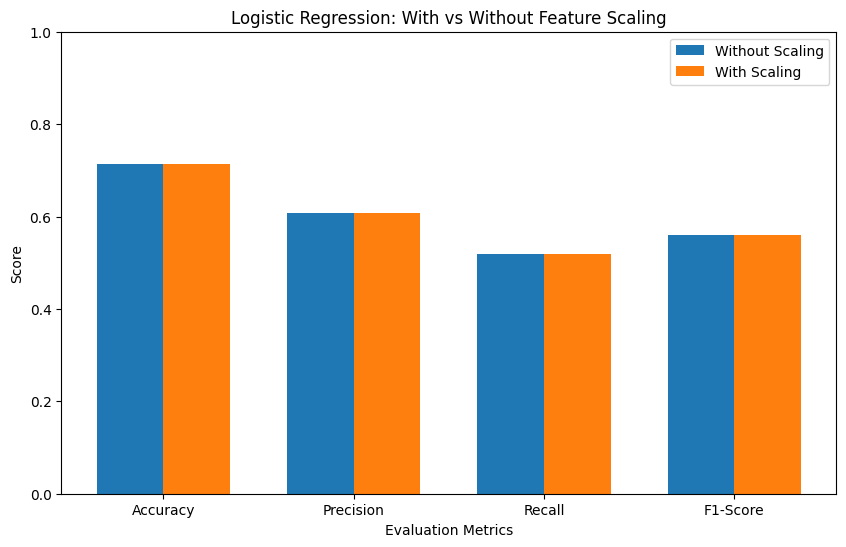

In [11]:
x = np.arange(len(results["Metric"]))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    results["Without Scaling"],
    width,
    label="Without Scaling"
)

plt.bar(
    x + width/2,
    results["With Scaling"],
    width,
    label="With Scaling"
)

plt.xticks(x, results["Metric"])
plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")
plt.title("Logistic Regression: With vs Without Feature Scaling")
plt.ylim(0, 1)
plt.legend()

plt.show()